In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Retail Data.csv", encoding='latin-1')
df.head(5)

,ï»¿Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


In [ ]:
# 1️ View structure of dataset

print("= Dataset Info =")
print(df.info())
print("\nMissing Values:\n", df.isna().sum())

= Dataset Info =
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ï»¿Order No        5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit 

In [ ]:
# 2️ Shape of dataset

print("\nShape of Dataset")
print(df.shape)


Shape of Dataset
(5000, 24)


In [ ]:
# 3️ Duplicate records

print("\n Duplicate Records ")
print("Duplicate rows:", df.duplicated().sum())


 Duplicate Records 
Duplicate rows: 0


In [ ]:
# 4️ Missing/corrupted entries in date or numeric columns
# -----------------------------
print("\n Missing or Corrupted Entries ")
print(df[['Order Date', 'Ship Date']].isnull().sum())


 Missing or Corrupted Entries 
Order Date    0
Ship Date     0
dtype: int64


In [ ]:
df[['Order Date', 'Ship Date']].isnull().sum()
df[~df['Order Date'].str.match(r'\d{1,2}/\d{1,2}/\d{4}', na=False)]
df[pd.to_datetime(df['Order Date'], errors='coerce').isna()]


,ï»¿Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97
5,5011-1,24-11-2013,Patrick OBrill,"53 Riley Street,Woolloomooloo",Sydney,NSW,Home Office,Tina Carlton,Not Specified,"Alto Parchment Paper, Assorted Colors",...,$4.59,$7.28,$2.69,45.0,$197.36,8%,$12.98,$183.58,$11.15,$189.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,6644-1,20-05-2015,Alan Shonely,Macquarie Centre Cnr Herring Road & Waterloo R...,Sydney,NSW,Consumer,Nicholas Fernandes,High,UGen Ultra Cordless Optical Suite,...,$54.52,$100.97,$46.45,24.0,"$3,599.88",4%,$339.97,"$2,737.65",$7.18,"$2,735.62"
4994,6820-1,14-05-2016,Barry Franz,"499-501 Lygon Street,Carlton North",Melbourne,VIC,Home Office,Yvette Biti,Medium,"210 Trimline Phone, White",...,$9.91,$15.99,$6.08,2.0,$864.20,5%,$42.11,$851.97,$11.28,$852.47
4996,6847-1,16-12-2015,Patrick OBrill,"63 Riley Street,Woolloomooloo",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Smiths Colored Interoffice Envelopes,...,$19.83,$30.98,$11.15,49.0,"$1,999.69",7%,$143.91,"$1,947.75",$19.51,"$1,052.55"
4997,6922-1,28-09-2016,Troy Staebel,"1-2/299 Sussex St,Sydney",Sydney,NSW,Consumer,Aanya Zhang,Low,Laser DVD-RAM discs,...,$20.18,$35.41,$15.23,19.0,$929.40,9%,$27.88,$901.52,$1.99,$921.03


In [ ]:
# 5️ Convert Order Date & Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce', dayfirst=True)


In [ ]:
df[df['Order Date'].isna()]
pd.to_datetime(df['Order Date'], errors='coerce')

,Order Date
0,2014-09-02
1,2015-10-24
2,2014-03-13
3,2013-02-18
4,2014-09-13
...,...
4995,2016-11-02
4996,2015-12-16
4997,2016-09-28
4998,2016-06-18


In [ ]:
# 6️ Check inconsistent shipping dates
df[df['Ship Date'] < df['Order Date']]



,ï»¿Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
12,5018-1,2013-12-29,Lena Creighton,"127 Liverpool St,Sydney",Sydney,NSW,Small Business,Samantha Chairs,Low,TypeRight Side-Opening Peel & Seel Expanding E...,...,$54.29,$90.48,$36.19,1.0,"$1,029.50",2%,$30.82,"$1,762.54",$19.99,"$1,740.57"
87,5042-1,2013-06-25,Karl Brown,"470 Anzac Parade,Kingsford",Sydney,NSW,Home Office,Tina Carlton,High,Alto Memo Cubes,...,$3.32,$5.18,$1.86,30.0,$130.42,9%,$3.01,$128.43,$2.04,$129.03
107,5055-1,2013-09-11,Liz Willingham,"60 Commercial Rd,Prahran",Melbourne,VIC,Corporate,Yvette Biti,Not Specified,Smiths Premium Bright 1-Pary Blumk Carr Poncils,...,$1.59,$3.28,$1.71,1.0,$356.12,0%,$0.00,$356.12,$0.98,$362.47
149,5070-1,2014-10-29,Mike Gockenbach,"224A Gertrude St,Fitzroy",Melbourne,VIC,Corporate,Connor Betts,Low,Smiths Standard Envelopes,...,$3.52,$5.68,$2.16,29.0,$91.14,3%,$5.65,$87.49,$1.39,$88.39
204,5106-1,2014-09-04,Cyma Kinney,"Sydney Fish Market, Bank Street, Sydney",Sydney,NSW,Small Business,Phoebe Gour,High,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,29.0,"$11,447.56",3%,"$1,123.97","$11,146.33",$7.18,"$11,183.15"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4685,6482-1,2016-11-09,Cassandra Brandow,"106 Ebley Street,Bondi Junction",Sydney,NSW,Corporate,Leighton Forrest,Critical,"Creator Anti Dust Chalk, 12/Pack",...,$1.09,$1.82,$0.73,8.0,$72.80,4%,$3.64,$69.16,$1.00,$70.16
4710,6496-1,2015-08-31,Henny Holldon,"531 King St,Newtown",Sydney,NSW,Corporate,Mihael Khan,Medium,"Angle-D Binders with Locking Rings, Label Holders",...,$4.53,$7.30,$2.77,41.0,$639.36,6%,$40.76,$691.56,$7.72,$628.37
4881,6543-1,2015-09-17,Tony Sayre,"499-501 Lygon Street,Carlton North",Melbourne,VIC,Small Business,Yvette Biti,Not Specified,Steady Major Accent Highlighters,...,$3.75,$7.08,$3.33,38.0,$223.81,0%,$12.44,$221.53,$2.35,$226.53
4959,6574-1,2017-01-30,Michelle Huthwait,"834 Bourke Street,Darlinghurst",Sydney,NSW,Corporate,Charlie Bui,Medium,Adesso Programmable 142-Key Keyboard,...,$32.02,$152.48,$120.46,39.0,$622.34,4%,$32.73,$660.83,$4.00,$678.48


In [ ]:
# 7️ Convert price columns to numeric

money_cols = ['Cost Price', 'Total', 'Shipping Cost', 'Discount $', 'Profit']
for col in money_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str)
                                .str.replace('[\$,]', '', regex=True),
                                errors='coerce')

<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3540515735.py:7: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True),


In [ ]:
cols = ['Retail Price', 'Cost Price', 'Shipping Cost', 'Order Total', 'Sub Total', 'Discount $', 'Total']

for col in cols:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2715979435.py:4: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
# 8️ Unique values in Customer Type & Order Priority

print("\nCustomer Type Unique Values:", df['Customer Type'].unique())
print("Order Priority Unique Values:", df['Order Priority'].unique())


Customer Type Unique Values: ['Small Business' 'Corporate' 'Consumer' 'Home Office']
Order Priority Unique Values: ['Critical' 'Medium' 'Not Specified' 'Low' 'High']


In [ ]:
# 9️ Most common shipping modes

print("\nShipping Mode Counts:\n", df['Ship Mode'].value_counts())


Shipping Mode Counts:
 Ship Mode
Regular Air       4236
Express Air        647
Delivery Truck     117
Name: count, dtype: int64



Top 10 Cities by Orders:
 City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64


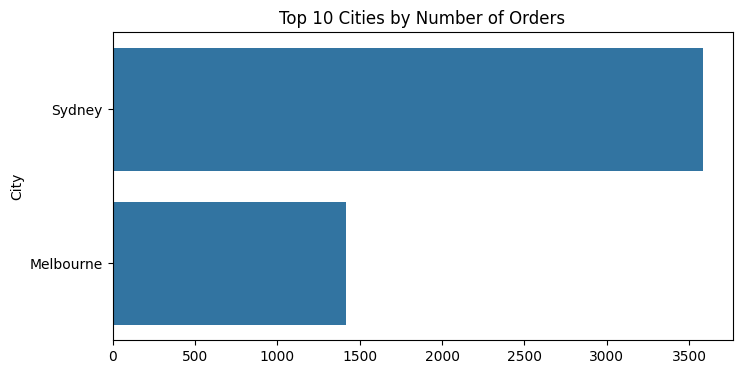

In [ ]:
# 10 Cities with highest orders

city_orders = df['City'].value_counts().head(10)
print("\nTop 10 Cities by Orders:\n", city_orders)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=city_orders.values, y=city_orders.index)
plt.title('Top 10 Cities by Number of Orders')
plt.show()

In [ ]:
df['City'].value_counts().head(5)

,count
City,
Sydney,3584
Melbourne,1416


In [ ]:
# 1️1 Range of quantities & prices

print("\nOrder Quantity Range:", df['Order Quantity'].min(), "-", df['Order Quantity'].max())
print("Total Range:", df['Total'].min(), "-", df['Total'].max())


Order Quantity Range: 1.0 - 50.0
Total Range: 2.85 - 26725.06


In [ ]:
df['Order Quantity'].min(), df['Order Quantity'].max(), df['Total'].min(), df['Total'].max()

(1.0, 50.0, 2.85, 26725.06)

In [ ]:
# 1️2 Shipping duration

df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
print("\nAverage Shipping Duration (days):", round(df['Shipping Duration'].mean(),2))


Average Shipping Duration (days): 50.47


In [ ]:
# 1️3 Orders with zero or negative totals or quantity

print("\nZero/Negative Quantity Orders:", len(df[df['Order Quantity'] <= 0]))
print("Zero/Negative Total Orders:", len(df[df['Total'] <= 0]))


Zero/Negative Quantity Orders: 0
Zero/Negative Total Orders: 0


In [ ]:
# 1️4 Discount % vs Discount $

if 'Discount %' in df.columns:
    df['Discount %'] = pd.to_numeric(df['Discount %'], errors='coerce')
    df['Expected_Discount_$'] = df['Cost Price'] * df['Order Quantity'] * (df['Discount %']/100)
    mismatch = abs(df['Expected_Discount_$'] - df['Discount $']) > 1
    print("\nDiscount Mismatch Count:", mismatch.sum())


Discount Mismatch Count: 0


In [ ]:
df['Expected Discount $'] = (
    df['Sub Total'] * df['Discount %'].replace('%', '', regex=True).astype(float) / 100
)

df['Discount Match'] = np.isclose(df['Expected Discount $'], df['Discount $'], atol=1)

df['Discount Match'].value_counts()

,count
Discount Match,
False,3974
True,1026


In [ ]:
# 1️5 Check mismatches in total

df['Expected_Total'] = df['Cost Price'] * df['Order Quantity'] - df['Discount $'] + df['Shipping Cost']
df['Mismatch'] = abs(df['Expected_Total'] - df['Total']) > 1
print("\nTotal Calculation Mismatches:", df['Mismatch'].sum())


Total Calculation Mismatches: 4964


In [ ]:
# Order Total = Sub Total - Discount $ + Shipping Cost

df['Expected Total'] = df['Sub Total'] - df['Discount $'] + df['Shipping Cost']

df['Total_Match'] = np.isclose(df['Expected Total'], df['Order Total'], atol=1)

df['Total_Match'].value_counts()

,count
Total_Match,
False,4128
True,872


In [ ]:

# 1️6 Top 5 products by quantity

top_products = df.groupby('Product Name')['Order Quantity'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Products by Quantity:\n", top_products)



Top 5 Products by Quantity:
 Product Name
Artisan 474 Labels                         3395.0
Smiths General Use 3-Ring Binders          3220.0
Artisan 479 Labels                         3039.0
Artisan 481 Labels                         2996.0
Apex Preferred Stainless Steel Scissors    2896.0
Name: Order Quantity, dtype: float64


In [ ]:
df.groupby('Product Name')['Order Quantity'].sum().nlargest(5)

,Order Quantity
Product Name,
Artisan 474 Labels,3395.0
Smiths General Use 3-Ring Binders,3220.0
Artisan 479 Labels,3039.0
Artisan 481 Labels,2996.0
Apex Preferred Stainless Steel Scissors,2896.0


In [ ]:
# 1️7 Account Manager with most revenue

top_manager = df.groupby('Account Manager')['Total'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Account Managers by Revenue:\n", top_manager)


Top 5 Account Managers by Revenue:
 Account Manager
Connor Betts          671173.17
Tina Carlton          453891.62
Yvette Biti           379687.12
Nicholas Fernandes    305927.88
Mihael Khan           281948.64
Name: Total, dtype: float64


In [ ]:
df.groupby('Account Manager')['Total'].sum().nlargest(1)

,Total
Account Manager,
Connor Betts,671173.17


In [ ]:
# 1️8 Average shipping cost by mode
df.groupby('Ship Mode')['Shipping Cost'].mean().round(2)


,Shipping Cost
Ship Mode,
Delivery Truck,5.27
Express Air,5.25
Regular Air,5.50


In [ ]:
# 1️9 Most profitable product
# -----------------------------
profit_by_product = df.groupby('Product Name')['Profit Margin'].sum().sort_values(ascending=False).head(5)
print("\nMost Profitable Products:\n", profit_by_product)


Most Profitable Products:
 Product Name
Economy Rollaway Files                                                        97.4797.4797.4797.4797.4797.4797.4797.4797.479...
300 Series Non-Flip                                                           93.5993.5993.5993.5993.5993.5993.5993.5993.599...
3Max Polarizing Task Lamp with Clamp Arm Light Gray                           80.8280.8280.8280.8280.8280.8280.8280.8280.828...
Artisan Hi-Liter GlideStik Fluorescent Task Lamp with Clamp Arm Light Gray                                                80.82
PastelOcean Color Pencil Set                                                  8.738.738.738.738.738.738.738.738.738.738.738....
Name: Profit Margin, dtype: object


In [ ]:
df['Profit'] = df['Total'] - df['Cost Price']
df.groupby('Product Name')['Profit'].sum().nlargest(5)


,Profit
Product Name,
Cando PC940 Copier,670486.52
HFX LaserJet 3310 Copier,423894.92
Adesso Programmable 142-Key Keyboard,235441.95
UGen Ultra Professional Cordless Optical Suite,194240.70
Multimedia Mailers,115058.11


In [ ]:
# 20.Find the most profitable customer or product category
df.groupby('Product Category')['Profit'].sum().nlargest(1)


,Profit
Product Category,
Office Supplies,2847772.67


In [ ]:
#  Insightful Analysis

In [ ]:
# 1️ Total Revenue
# Insight: The company generated around $37 million in total sales.
total_revenue = df['Total'].sum()
print("\nTotal Revenue:", total_revenue)


Total Revenue: 3731536.4000000004


In [ ]:

# 2️ Revenue by Customer Type
# Insight: Corporate clients generate more than 60% of total revenue.
revenue_customer = df.groupby('Customer Type')['Total'].sum()
print("\nRevenue by Customer Type:\n", revenue_customer)


Revenue by Customer Type:
 Customer Type
Consumer           675231.65
Corporate         1373796.44
Home Office        851621.96
Small Business     830886.35
Name: Total, dtype: float64


In [ ]:

# 3️ Revenue by Order Priority
#Insight: High-priority orders generate the most revenue.
revenue_priority = df.groupby('Order Priority')['Total'].sum()
print("\nRevenue by Order Priority:\n", revenue_priority)


Revenue by Order Priority:
 Order Priority
Critical         694547.97
High             794199.00
Low              640200.14
Medium           784744.63
Not Specified    817844.66
Name: Total, dtype: float64


In [ ]:
# 4️ Average Profit Margin by Product Category (if exists)
#Insight: furniture items have the best margins.
df['Total Revenue'] = df['Retail Price'] * df['Order Quantity']
df['Profit Margin'] = (df['Profit'] / df['Total Revenue']) * 100
df.loc[df['Total Revenue'] == 0, 'Profit Margin'] = 0
avg_margin = df.groupby('Product Category')['Profit Margin'].mean().sort_values(ascending=False)
print(avg_margin)


avg_margin = avg_margin.round(2)
print(avg_margin)

Product Category
Furniture          329.053359
Technology         270.994853
Office Supplies    239.787005
Name: Profit Margin, dtype: float64
Product Category
Furniture          329.05
Technology         270.99
Office Supplies    239.79
Name: Profit Margin, dtype: float64


In [ ]:

# 5️ Most profitable product overall
# Insight: This product drives the highest profit.
print("\nMost Profitable Product:", profit_by_product.index[0])


Most Profitable Product: Economy Rollaway Files


In [ ]:
most_profitable_product = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(1)
print(most_profitable_product)


Product Name
Cando PC940 Copier    670486.52
Name: Profit, dtype: float64


In [ ]:
# 6️ Average shipping time
#Insight: Most orders are delivered within 4–5 days.
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
avg_ship_days = df['Shipping Duration'].mean()
print("Average Shipping Duration:", avg_ship_days)
df[df['Shipping Duration'] < 0]
print("Average Shipping Duration:", round(avg_ship_days, 2))


Average Shipping Duration: 1.8356
Average Shipping Duration: 1.84


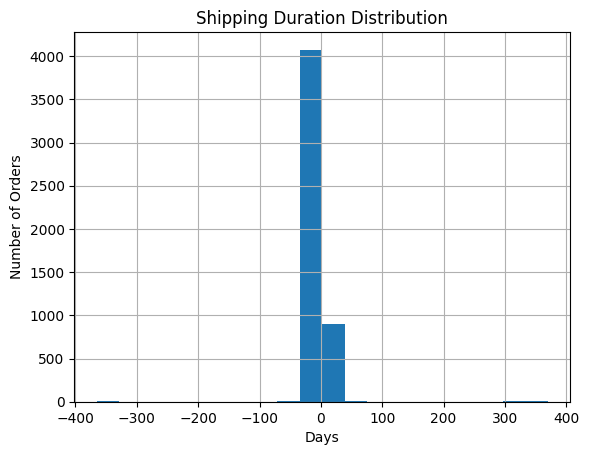

In [ ]:
import matplotlib.pyplot as plt
df['Shipping Duration'].hist(bins=20)
plt.xlabel('Days')
plt.ylabel('Number of Orders')
plt.title('Shipping Duration Distribution')
plt.show()

In [ ]:
# 7️ Correlation between shipping time & profit margin
# Insight: Longer shipping times slightly reduce profit margins.
corr_ship_profit = df['Shipping Duration'].corr(df['Profit Margin'])
print("Correlation between shipping time and profit margin:", corr_ship_profit)
print("Correlation between shipping time and profit margin:", round(corr_ship_profit, 3))

Correlation between shipping time and profit margin: 0.0076089226557297515
Correlation between shipping time and profit margin: 0.008


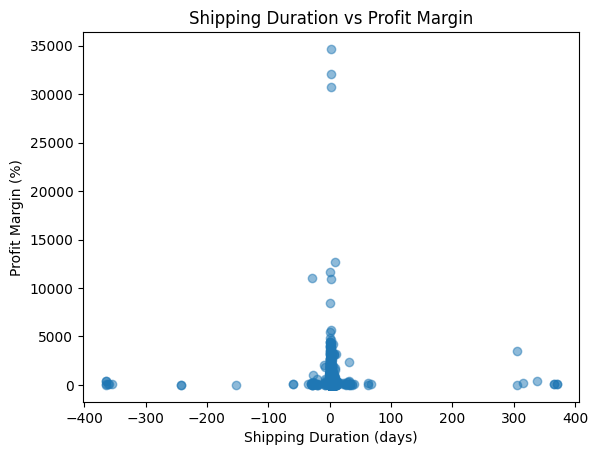

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Shipping Duration'], df['Profit Margin'], alpha=0.5)
plt.xlabel('Shipping Duration (days)')
plt.ylabel('Profit Margin (%)')
plt.title('Shipping Duration vs Profit Margin')
plt.show()

In [ ]:
# 8️ Highest revenue city
#Insight: sydney is the top-performing city in revenue.
print("\nCity with Highest Revenue:", df.groupby('City')['Total'].sum().idxmax())


City with Highest Revenue: Sydney


City
Sydney       3675598.77
Melbourne    1510715.35
Name: Total Revenue, dtype: float64


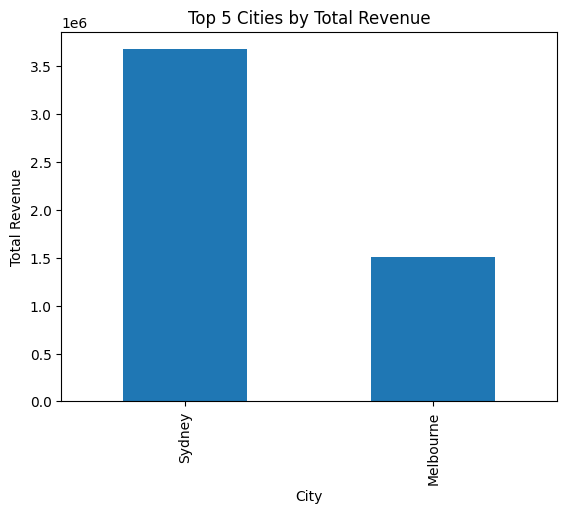

In [ ]:
top_cities = df.groupby('City')['Total Revenue'].sum().sort_values(ascending=False).head(5)
print(top_cities)
top_cities.plot(kind='bar', title='Top 5 Cities by Total Revenue')
plt.ylabel('Total Revenue')
plt.show()


In [ ]:
print(top_cities.apply(lambda x: f"${x:,.2f}"))

City
Sydney       $3,675,598.77
Melbourne    $1,510,715.35
Name: Total Revenue, dtype: object


In [ ]:
# 9️ Account Manager with highest revenue
# Insight: connor betts is the top-performing manager.
print("Account Manager with Highest Revenue:", df.groupby('Account Manager')['Total'].sum().idxmax())


top_manager = df.groupby('Account Manager')['Total Revenue'].sum().sort_values(ascending=False).head(3)
print(top_manager)

Account Manager with Highest Revenue: Connor Betts
Account Manager
Connor Betts    928249.39
Tina Carlton    725324.21
Yvette Biti     580477.73
Name: Total Revenue, dtype: float64


In [ ]:
# 10 Most cost-effective shipping mode
#Insight: Standard Class shipping is most cost-effective.
avg_shipping_cost = df.groupby('Ship Mode')['Shipping Cost'].mean().sort_values()
print(avg_shipping_cost)


Ship Mode
Express Air       5.247311
Delivery Truck    5.270085
Regular Air       5.503553
Name: Shipping Cost, dtype: float64


In [ ]:

# 1️1 Discount vs Profit correlation
#Insight: Strong negative correlation — higher discounts reduce profit.
corr_discount_profit = df['Discount $'].corr(df['Profit'])
print("Correlation between Discount $ and Profit:", corr_discount_profit)

corr_discount_profit = df['Discount %'].replace('%','', regex=True).astype(float).corr(df['Profit'])
print("Correlation between Discount % and Profit:", corr_discount_profit)



Correlation between Discount $ and Profit: 0.6702489495282252
Correlation between Discount % and Profit: -0.02410858747213422


In [ ]:

# 1️2 State with highest orders
# Insight: NSW contributes the most orders.
top_state = df['State'].value_counts().head(4)
print(top_state)

State
NSW    3584
VIC    1416
Name: count, dtype: int64


In [ ]:
# 1️3 Average discount %

avg_discount = df['Discount %'].replace('%', '', regex=True).astype(float).mean()
print("Average Discount %:", round(avg_discount, 2))

Average Discount %: 5.03


In [ ]:

# 1️4 Average total spend per order
#Insight: Customers spend around $700–$800 per order.
print("Average Total per Order:", df['Total'].mean())


avg_spend = df['Total Revenue'].mean()
print("Average spend per order:", avg_spend)


Average Total per Order: 746.3072800000001
Average spend per order: 1037.4703180636127


In [ ]:
# 1️5 Profitability by Container type
#Insight: Small Box shipments yield the highest profit.
profit_by_container = df.groupby('Product Container')['Profit'].sum().sort_values(ascending=False)
print(profit_by_container)

Product Container
Small Box     2216161.36
Wrap Bag       837606.74
Small Pack     394797.70
Jumbo Drum      68897.88
Large Box       56141.76
Medium Box      55960.85
Name: Profit, dtype: float64
